In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from scipy import fft

%config InlineBackend.figure_formats = ['svg']

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

FIR filters can be designed with a method called **windowing**.
This method makes use of the relation between impulse response $h[n]$ and frequency response $H[f]$ through the Fourier transform:

$$
H[f] = \mathcal{F}\{ h[n]\}
$$

In the windowing method, the following steps are applied to create FIR filter coefficients for a desired frequency response:

- 1: Define magnitude response in the frequency domain
- 2: Calculate impulse response (IR) with inverse Fourier transform
- 3: Truncate - or *window* - the IR 

----

# Ideal Lowpass Example

## Frequency Response

The frequeny response of an ideal lowpass is defined as a boxcar window, centered at $f=0$. It is ideal, in the sense that pass-band and stop-band are perfectly flat and the slope is infinite:

$$
H[f] = 
\begin{cases}
  1 & \text{if $|f| \leq f_c$ } \\
  0 & \text{otherwise}
\end{cases} 
$$

The figure below shows the ideal lowpass for $f_c = 1000 \mathrm{Hz}$ at a sampling rate of $f_s = 48 \mathrm{kHz}$:

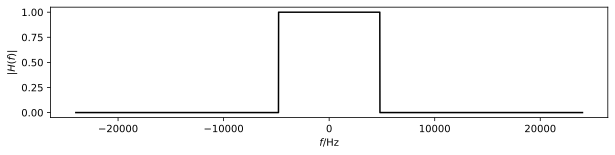

In [2]:
fs = 48000
N  = 10000

f0 = 1000
W  = 1000
X  = np.zeros(N)

X[int(N/2-W) : int(N/2+W)] =1


f  = np.linspace(-fs/2,fs/2,N)
k  = np.linspace(0,N-1,N)

fig = plt.figure(figsize=(10, 2))

ax1 = plt.subplot(1,1,1)
#ax1.set_title('$A=1$, $T=0.0125  \mathrm{s}$')
ax1.plot(f,X,'k')
ax1.set_xlabel("$f / \mathrm{Hz}$");
ax1.set_ylabel("$|H(f)|$");




#fig.tight_layout(pad=1);


## Impulse Response 

In order to get the impulse response for the ideal filter above, we need to apply the inverse Fourier transform (IFFT).
From the Fourier transform introduction we know that the [Fourier transform of a boxcar window](https://ringbuffer.org/dsp/Fourier_Transform/fourier-boxcar/) is a sinc function. This also applies to the IFFT.

Inserting $f_c$ this results in:

$$
\begin{eqnarray}
\mathcal h[n] & =  & {2 f_c}  \frac{\sin (2 \pi  n f_c)} {2 \pi  n f_c}\\
& =  &  {\frac{1}{2 f_c}  ~ \mathrm{sinc}(2 \pi  n f_c)} \\
\end{eqnarray}
$$

-----

## Truncation & Transform

The resulting impulse response $h[n]$ has $N=f_s$ samples. It can be directly applied by convolution with an input signal.
However an FIR filter with the order $48000$ introduce a significant delay and a high processing cost.

To reduce the order, a window is applied in the time domain to truncate the IR. This example shows this for a 
boxcar window with $\hat{N}=40$ samples.

- The first plot below shows the impulse response $h[n]$ with the windowing function $w[n]$.
- The second plot shows the truncated IR $\hat{h}[n]$.
- The third plot shows the Fourier transform of $h[t]$ - this is the frequency response of our truncated filter.

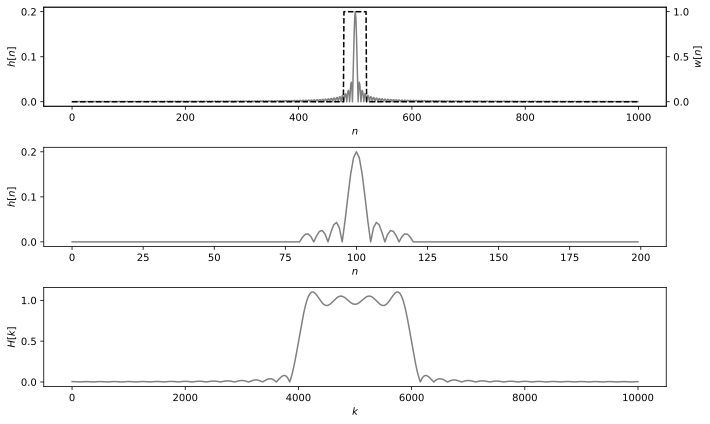

In [3]:
fig = plt.figure(figsize=(10, 6))

x  = fft.fftshift(fft.ifft((X)))
ax = plt.subplot(3,1,1)

XX  = np.zeros(N)
WW = 20
XX[int(N/2-WW) : int(N/2+WW)] =1
WW = 500



ax.plot(abs(x[int(N/2-WW) : int(N/2+WW)]),'gray')
ax2 = ax.twinx()
ax2.plot(abs(XX[int(N/2-WW) : int(N/2+WW)]),'k--')

ax.set_ylabel("$h[n]$");
ax.set_xlabel("$n$");
ax2.set_ylabel("$w[n]$");

xs = x*XX

ax1 = plt.subplot(3,1,2)
#ax1.set_title('Zoom into $h[n]$')
#ax1.plot(np.arange(300,700), abs(x[300:700]),'k')
ax1.plot(abs(xs[4900:5100]),'gray')
ax1.set_ylabel("$h[n]$");
ax1.set_xlabel("$n$");


plt.subplot(3,1,3)

plt.plot(abs((fft.fft(xs))),'gray')
plt.ylabel("$H[k]$");
plt.xlabel("$k$");

fig.tight_layout(pad=1);

-----

## Frequency Response in Detail

The figure below shows the frequency response of the low-pass filter obtained through the windowing method.
The resulting shape can be explained as a convolution of the ideal boxcar with a sinc function - the Fourier transform of the window used to truncate the impulse response.

The previously ideal window is now affected by **Gibb's phenomenon**. This is the same effect that occurs when a signal is approximated through a Fourier series.

- We see an **overshoot** - the gain goes above $1.0$ in the pass-band.
- The **pass-band ripples** have a gain of 0.08.
- The **stop-band ripples** have a gain of 0.075.


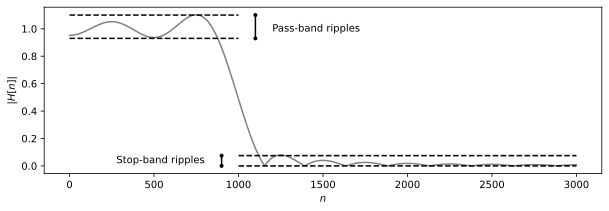

In [4]:
fig = plt.figure(figsize=(10, 3))

plt.plot(abs((fft.fft(xs)))[5000:8000],'gray');

plt.plot([0,1000],[1.1,1.1],'k--');
plt.plot([0,1000],[0.93,0.93],'k--');
plt.plot([1100,1100],[0.93,1.1],'k', marker=".");
plt.text(1200, 1, 'Pass-band ripples', horizontalalignment='left',     verticalalignment='center')


plt.plot([1000, 3000],[0.075,0.075],'k--');
plt.plot([1000, 3000],[0,0],'k--');
plt.plot([900,900],[0,0.075],'k', marker=".");
plt.text(800, 0.04, 'Stop-band ripples', horizontalalignment='right',     verticalalignment='center')

 

plt.ylabel("$|H[n]|$");
plt.xlabel("$n$");